# Ensemble Learning: Random Forest — Sampling Strategies from Scratch

---

## Introduction

**Random Forest** is an ensemble of Decision Trees where each tree is trained on a different random subset of the data. The key insight is that introducing randomness at two levels — **row sampling** and **feature (column) sampling** — creates diverse trees whose errors are largely uncorrelated. When their predictions are aggregated via majority vote, individual errors cancel out, producing a model with lower variance and better generalization than any single tree.

This notebook builds the core mechanics of Random Forest **from scratch**, manually implementing the three sampling strategies that define it:

| Strategy | What is randomized | Analogy in sklearn |
|---|---|---|
| **Row Sampling** | Random rows with replacement (bootstrap) | `BaggingClassifier(bootstrap=True)` |
| **Column Sampling** | Random feature subsets per tree | `max_features` in `RandomForestClassifier` |
| **Combined Sampling** | Both rows and columns randomly | Full Random Forest behavior |

For each strategy, three `DecisionTreeClassifier` instances are trained on independently sampled subsets, their tree structures are visualized, and their predictions on a test point are compared to illustrate the diversity that emerges.

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree

import warnings
warnings.filterwarnings('ignore')

random.seed(42)

---

## 2. Dataset

We generate a small synthetic classification dataset with 100 samples and 5 fully informative features. Using a synthetic dataset with no redundant features ensures each column carries real signal, which makes the effect of column sampling more meaningful to observe.

| Parameter | Value | Meaning |
|---|---|---|
| `n_samples` | 100 | Total samples |
| `n_features` | 5 | Total features |
| `n_informative` | 5 | All features carry signal |
| `n_redundant` | 0 | No duplicate/correlated features |
| `n_clusters_per_class` | 1 | Simple class structure |

In [2]:
X, y = make_classification(
    n_samples=100, n_features=5, n_informative=5,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y

print('Shape:', df.shape)
df.head()

Shape: (100, 6)


,col1,col2,col3,col4,col5,target
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
1,3.243492,1.666651,3.179016,-0.825861,0.778528,1
2,0.712446,-1.201617,1.528624,-0.422788,-0.376825,0
3,1.388329,1.538995,1.243716,0.740905,-2.081063,1
4,2.394647,-3.576345,0.914217,0.363136,2.110329,0


---

## 3. Sampling Helper Functions

Three utility functions implement the sampling strategies. Each returns a new DataFrame, leaving the original untouched.

In [3]:
def sample_rows(df, percent):
    """Bootstrap sample: draw `percent` of rows with replacement."""
    n = int(percent * df.shape[0])
    return df.sample(n, replace=True)


def sample_features(df, percent):
    """Feature sample: draw `percent` of feature columns randomly (without replacement)."""
    feature_cols = df.columns.tolist()[:-1]  # exclude target
    n_cols = int(percent * len(feature_cols))
    selected = random.sample(feature_cols, n_cols)
    return df[selected + ['target']].copy()


def combined_sampling(df, row_percent, col_percent):
    """Combined: first bootstrap sample rows, then sample feature columns."""
    return sample_features(sample_rows(df, row_percent), col_percent)

---

## 4. Strategy 1 — Row Sampling (Bootstrap)

Each of the three trees is trained on a bootstrap sample of 10% of rows (10 samples), using all 5 features. The trees will differ solely because they each saw a different random subset of training examples.

This is the variance-reduction mechanism in standard **Bagging**.

In [4]:
# Draw three independent bootstrap samples (10% of rows each)
df1 = sample_rows(df, 0.1)
df2 = sample_rows(df, 0.1)
df3 = sample_rows(df, 0.1)

print(f"Sample sizes — df1: {len(df1)}, df2: {len(df2)}, df3: {len(df3)}")
print("Features used:", df1.columns.tolist()[:-1])

Sample sizes — df1: 10, df2: 10, df3: 10
Features used: ['col1', 'col2', 'col3', 'col4', 'col5']


In [5]:
# Train one Decision Tree per bootstrap sample
clf1 = DecisionTreeClassifier(random_state=1)
clf2 = DecisionTreeClassifier(random_state=2)
clf3 = DecisionTreeClassifier(random_state=3)

clf1.fit(df1.iloc[:, :-1], df1['target'])
clf2.fit(df2.iloc[:, :-1], df2['target'])
clf3.fit(df3.iloc[:, :-1], df3['target'])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
# Predict on a test point — observe whether trees agree or disagree
test_point = np.array([1.053909, -3.861208, 1.530963, 0.596692, 1.030284]).reshape(1, 5)

p1 = clf1.predict(test_point)[0]
p2 = clf2.predict(test_point)[0]
p3 = clf3.predict(test_point)[0]
majority = max([p1, p2, p3], key=[p1, p2, p3].count)

print("Row Sampling — Individual Predictions:")
print(f"  Tree 1 : {p1}")
print(f"  Tree 2 : {p2}")
print(f"  Tree 3 : {p3}")
print(f"  Majority vote : {majority}")

Row Sampling — Individual Predictions:
  Tree 1 : 0
  Tree 2 : 0
  Tree 3 : 0
  Majority vote : 0


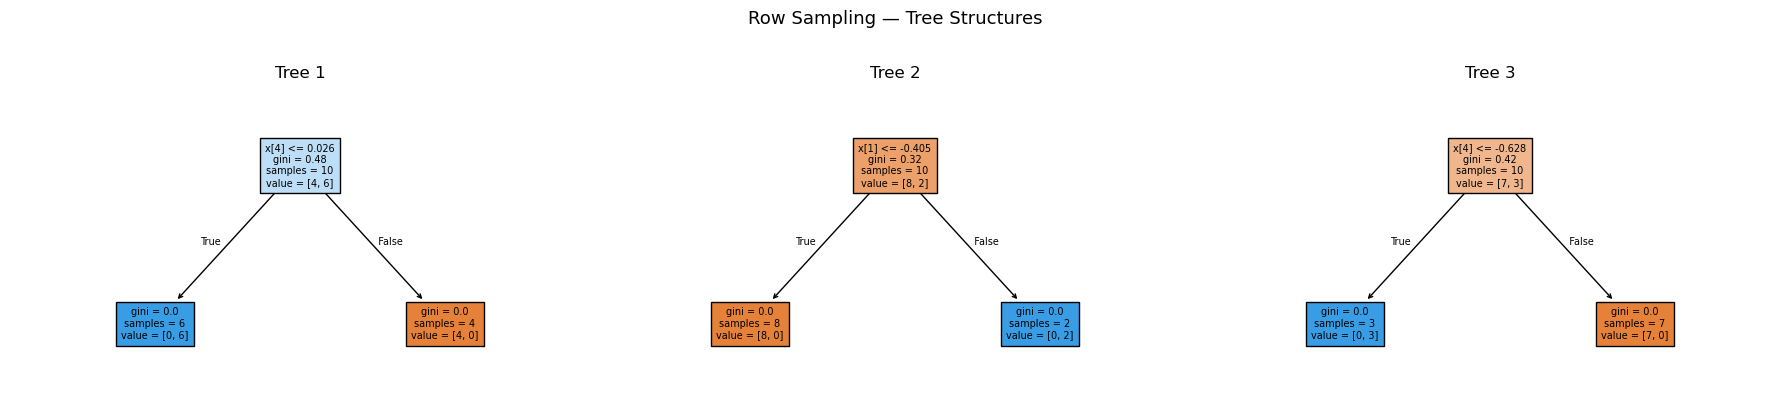

In [7]:
# Visualize tree structures to see how bootstrap diversity affects splits
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, clf, title in zip(axes, [clf1, clf2, clf3], ['Tree 1', 'Tree 2', 'Tree 3']):
    plot_tree(clf, ax=ax, filled=True, fontsize=7)
    ax.set_title(title)
plt.suptitle('Row Sampling — Tree Structures', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Strategy 2 — Column (Feature) Sampling

Each tree now trains on the **full 100 rows** but only a randomly selected **50% of features** (2 out of 5). The feature subset is re-drawn independently for each tree.

This is the defining addition that distinguishes **Random Forest** from plain Bagging — forcing each tree to consider different features at training time decorrelates the trees even when they are trained on the same data.

In [8]:
# Draw three independent feature subsets (50% of columns each)
df1 = sample_features(df, 0.5)
df2 = sample_features(df, 0.5)
df3 = sample_features(df, 0.5)

print("Features selected per tree:")
print(f"  Tree 1 : {df1.columns.tolist()[:-1]}")
print(f"  Tree 2 : {df2.columns.tolist()[:-1]}")
print(f"  Tree 3 : {df3.columns.tolist()[:-1]}")

Features selected per tree:
  Tree 1 : ['col1', 'col5']
  Tree 2 : ['col3', 'col2']
  Tree 3 : ['col2', 'col5']


In [9]:
# Train one Decision Tree per feature-sampled dataset
clf1 = DecisionTreeClassifier(random_state=1)
clf2 = DecisionTreeClassifier(random_state=2)
clf3 = DecisionTreeClassifier(random_state=3)

clf1.fit(df1.iloc[:, :-1], df1['target'])
clf2.fit(df2.iloc[:, :-1], df2['target'])
clf3.fit(df3.iloc[:, :-1], df3['target'])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
# Each tree uses 2 features — the test point must match the selected columns
def predict_with_subset(clf, df_subset, values):
    feat_cols = df_subset.columns.tolist()[:-1]
    return clf.predict(np.array(values).reshape(1, -1))[0]

# Use the first two values of a sample point matching the 2-feature subsets
test_point_2d = np.array([3.243492, -0.825861]).reshape(1, 2)

p1 = clf1.predict(test_point_2d)[0]
p2 = clf2.predict(test_point_2d)[0]
p3 = clf3.predict(test_point_2d)[0]
majority = max([p1, p2, p3], key=[p1, p2, p3].count)

print("Column Sampling — Individual Predictions:")
print(f"  Tree 1 : {p1}")
print(f"  Tree 2 : {p2}")
print(f"  Tree 3 : {p3}")
print(f"  Majority vote : {majority}")

Column Sampling — Individual Predictions:
  Tree 1 : 1
  Tree 2 : 0
  Tree 3 : 1
  Majority vote : 1


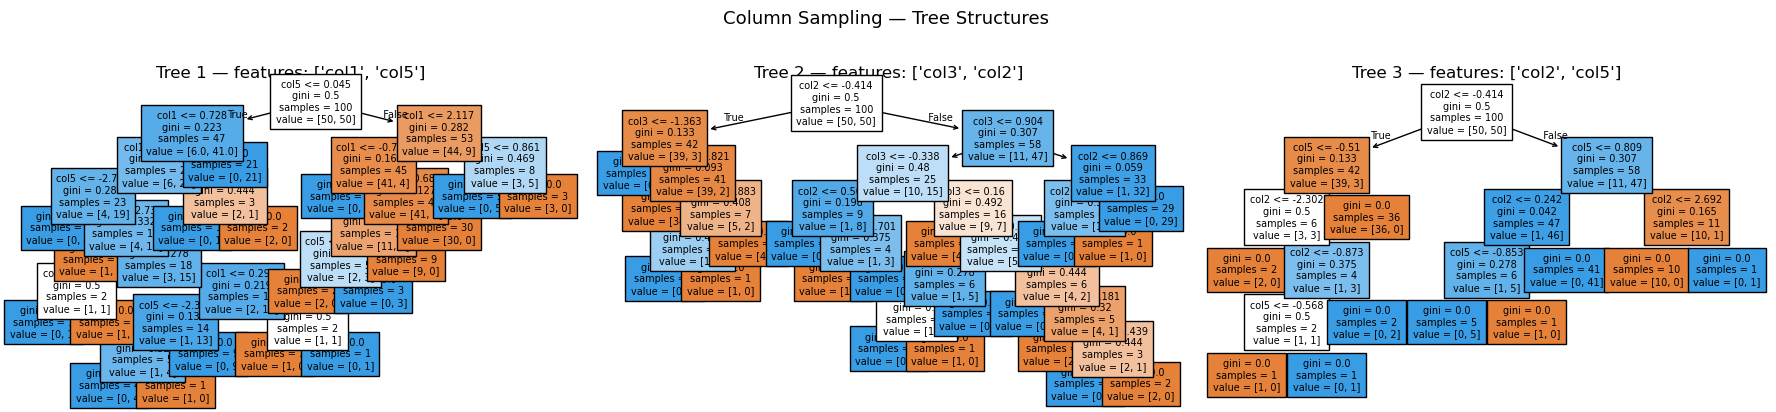

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, clf, d, title in zip(axes, [clf1, clf2, clf3], [df1, df2, df3], ['Tree 1', 'Tree 2', 'Tree 3']):
    plot_tree(clf, feature_names=d.columns.tolist()[:-1], ax=ax, filled=True, fontsize=7)
    ax.set_title(f"{title} — features: {d.columns.tolist()[:-1]}")
plt.suptitle('Column Sampling — Tree Structures', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Strategy 3 — Combined Sampling (Full Random Forest)

Combined sampling applies both strategies together: each tree is trained on a **bootstrap sample of rows** (50%) **and** a **random subset of features** (50%). This is exactly how `sklearn.ensemble.RandomForestClassifier` works internally — the only difference is that sklearn randomizes features at each split node rather than once per tree.

This strategy produces the most diverse trees and generally yields the best ensemble performance.

In [12]:
# Draw three combined samples (50% rows + 50% features)
df1 = combined_sampling(df, 0.5, 0.5)
df2 = combined_sampling(df, 0.5, 0.5)
df3 = combined_sampling(df, 0.5, 0.5)

print("Combined Sampling — Dataset shapes and features:")
for i, d in enumerate([df1, df2, df3], 1):
    print(f"  Tree {i} : {d.shape[0]} rows, features: {d.columns.tolist()[:-1]}")

Combined Sampling — Dataset shapes and features:
  Tree 1 : 50 rows, features: ['col1', 'col5']
  Tree 2 : 50 rows, features: ['col5', 'col4']
  Tree 3 : 50 rows, features: ['col1', 'col5']


In [13]:
clf1 = DecisionTreeClassifier(random_state=1)
clf2 = DecisionTreeClassifier(random_state=2)
clf3 = DecisionTreeClassifier(random_state=3)

clf1.fit(df1.iloc[:, :-1], df1['target'])
clf2.fit(df2.iloc[:, :-1], df2['target'])
clf3.fit(df3.iloc[:, :-1], df3['target'])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
test_point_2d = np.array([1.421116, -0.263938]).reshape(1, 2)

p1 = clf1.predict(test_point_2d)[0]
p2 = clf2.predict(test_point_2d)[0]
p3 = clf3.predict(test_point_2d)[0]
majority = max([p1, p2, p3], key=[p1, p2, p3].count)

print("Combined Sampling — Individual Predictions:")
print(f"  Tree 1 : {p1}")
print(f"  Tree 2 : {p2}")
print(f"  Tree 3 : {p3}")
print(f"  Majority vote : {majority}")

Combined Sampling — Individual Predictions:
  Tree 1 : 0
  Tree 2 : 0
  Tree 3 : 1
  Majority vote : 0


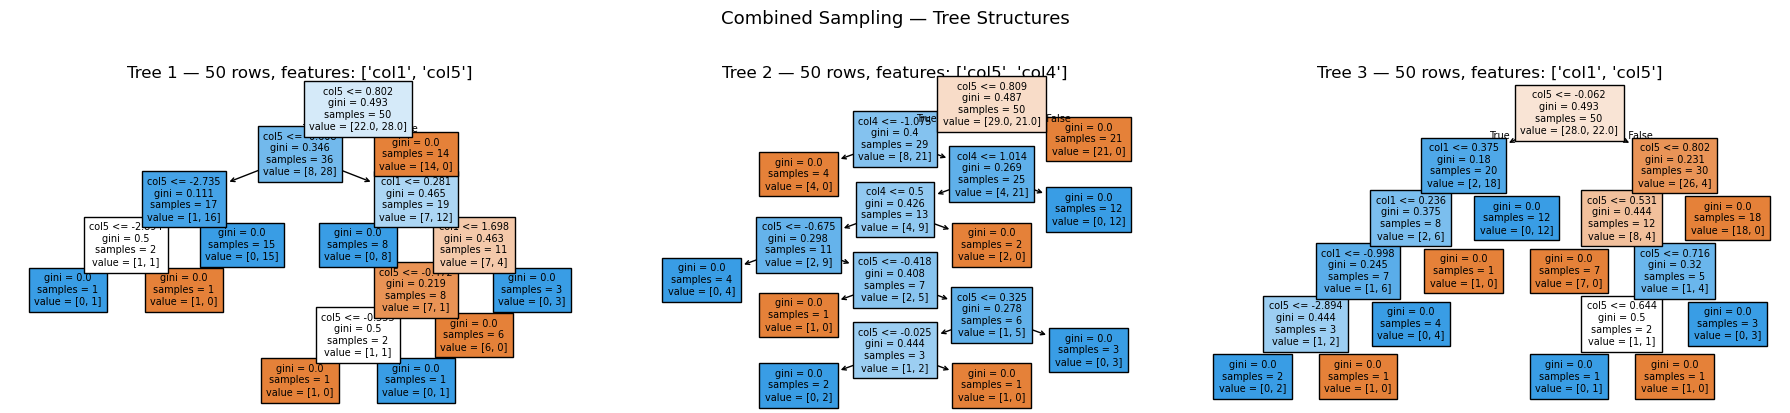

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, clf, d, title in zip(axes, [clf1, clf2, clf3], [df1, df2, df3], ['Tree 1', 'Tree 2', 'Tree 3']):
    plot_tree(clf, feature_names=d.columns.tolist()[:-1], ax=ax, filled=True, fontsize=7)
    ax.set_title(f"{title} — {d.shape[0]} rows, features: {d.columns.tolist()[:-1]}")
plt.suptitle('Combined Sampling — Tree Structures', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## Conclusion

This notebook built the core mechanics of Random Forest from scratch, implementing and comparing three progressive sampling strategies on a synthetic 5-feature classification dataset.

**Key findings:**

- **Row sampling alone** (bagging) creates tree diversity by exposing each estimator to a different subset of training examples. Trees trained on 10% bootstrap samples still produce meaningfully different splits, visible in the tree structure plots.
- **Column sampling alone** produces perhaps the most striking diversity — by restricting each tree to a random 50% of features, the trees are structurally forced to use different variables and learn complementary decision boundaries even on the same data.
- **Combined sampling** stacks both effects, maximizing diversity across the ensemble. Each tree is simultaneously trained on fewer rows and fewer features, creating highly independent estimators whose errors are minimally correlated.
- The majority vote aggregation step is visible in the prediction blocks — when individual trees disagree, the ensemble still resolves to a single label, demonstrating the error-cancellation effect that makes Random Forest robust.

**Takeaways:**

- The power of Random Forest comes entirely from **diversity** among base trees. More diverse trees → less correlated errors → stronger ensemble.
- Column sampling at the **split level** (as sklearn's `RandomForestClassifier` does) is even more powerful than per-tree feature sampling demonstrated here, because a single tree can use different feature subsets at every node.
- `sklearn.ensemble.RandomForestClassifier` automates all of this — understanding these manual steps makes its hyperparameters (`n_estimators`, `max_features`, `max_samples`) intuitive to tune.
- The next natural step is **AdaBoost** and **Gradient Boosting**, which build trees sequentially rather than in parallel, focusing each new tree on the errors of the previous ones.